In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
import os
import warnings


 🚀 STARTING: BL FX STRATEGY (ARIMA + GARCH)

[3] Executing Backtest on period: 2024-01-01 -> 2025-12-31...
--------------------------------------------------------------------------------------------------------------
DATE         | EQUITY ($)   | LEV  | ALLOCATION (Next Period)
--------------------------------------------------------------------------------------------------------------
2024-01-03 | 996,774 | 3.9x | L: [GBPUSD:55%] | S: [USDCHF:-100%, USDNOK:-78%, USDTRY:-100%, USDZAR:-54%]
2024-02-07 | 908,193 | 4.7x | L: [USDMXN:100%, USDTRY:26%, USDZAR:100%] | S: [EURJPY:-100%, GBPUSD:-73%, USDNOK:-71%]
2024-03-06 | 845,252 | 6.0x | L: [AUDJPY:100%, EURJPY:100%, NZDJPY:100%, USDJPY:100%, USDZAR:37%] | S: [USDNOK:-63%, USDTRY:-100%]
2024-04-03 | 903,799 | 6.0x | L: [USDCHF:100%, USDNOK:100%, USDSEK:100%] | S: [AUDUSD:-15%, EURUSD:-58%, GBPUSD:-100%, NZDUSD:-27%, USDTRY:-100%]
2024-05-01 | 896,967 | 3.4x | L: [AUDJPY:100%, AUDUSD:100%] | S: [USDNOK:-100%, USDSEK:-20%, USDZAR:-21%]
20

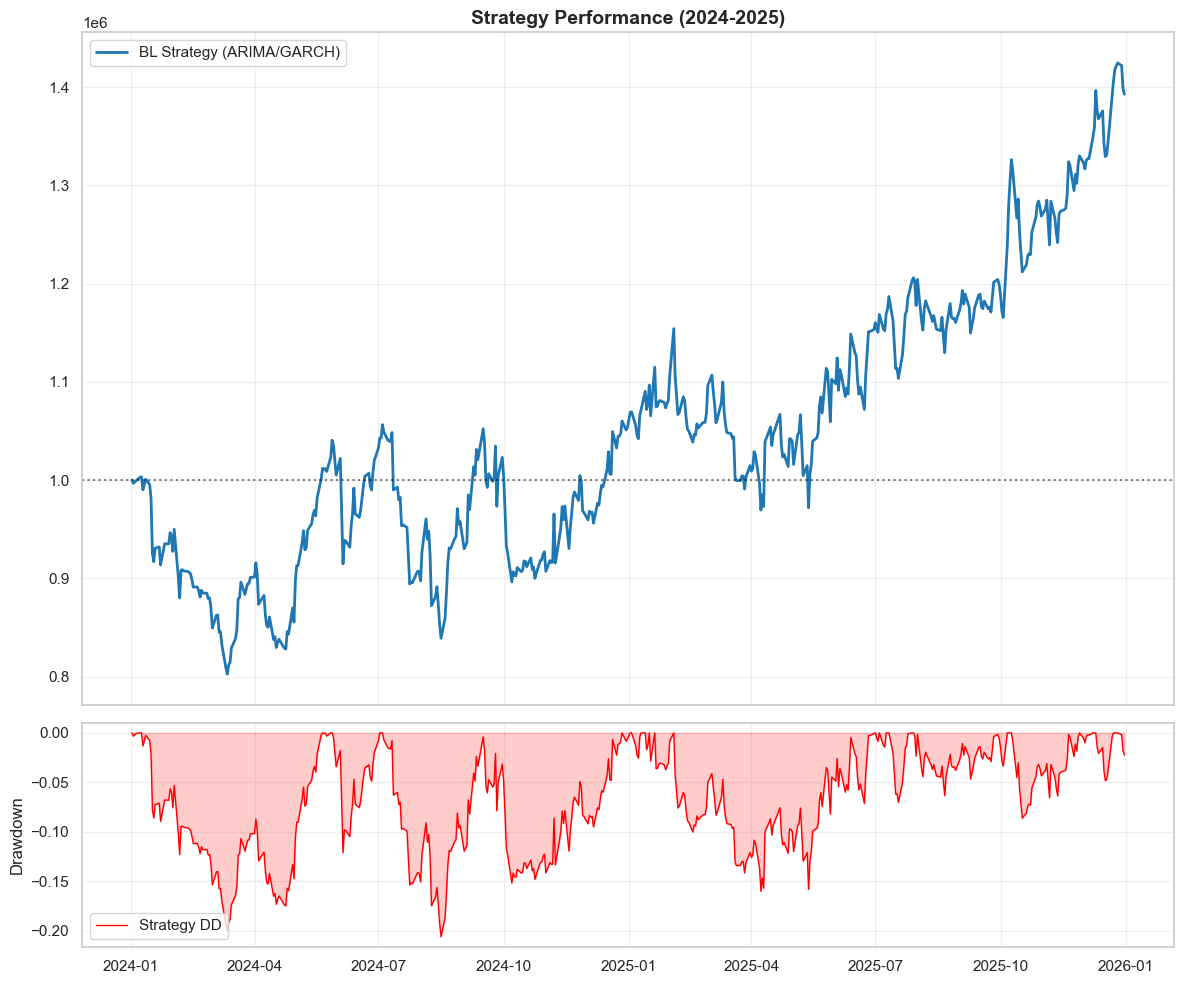

In [6]:
# ==============================================================================
# 1. CONFIGURATION & SETUP
# ==============================================================================
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
sns.set_theme(style="whitegrid")

OUTPUT_DIR = "backtest_results_arima_strict"
if not os.path.exists(OUTPUT_DIR): os.makedirs(OUTPUT_DIR)
FILE_RETURNS = os.path.join(OUTPUT_DIR, "MASTER_RETURNS_ARIMA_BL.csv")

TARGET_BUDGET = 1000000.0   
LOOKBACK_COV = 126           

# [OPTIMISATION 1] : Paramètres ARIMA
ARIMA_ORDER = (1, 0, 0)      
ARIMA_WINDOW = 60            

# [OPTIMISATION 2] : Paramètres GARCH et Levier
MIN_LEVERAGE = 2.0
MAX_LEVERAGE = 6.0
TARGET_VOL_ANNUAL = 0.12     

DEFAULT_COST = 0.0005 
BROKER_SWAP_MARKUP = 0.0050 
SPECIFIC_SPREADS = {
    'EURUSD': 0.00012, 'USDJPY': 0.00012, 'GBPUSD': 0.00015, 
    'AUDUSD': 0.00015, 'USDCAD': 0.00018, 'USDCHF': 0.00018, 'NZDUSD': 0.00020,
    'EURGBP': 0.00020, 'EURJPY': 0.00022, 'GBPJPY': 0.00028,
    'AUDJPY': 0.00025, 'CADJPY': 0.00025, 'CHFJPY': 0.00025,
    'EURAUD': 0.00030, 'EURCAD': 0.00030, 'GBPAUD': 0.00035, 'GBPCAD': 0.00035,
    'AUDNZD': 0.00035, 'AUDCAD': 0.00030,
    'USDMXN': 0.00100, 'USDZAR': 0.00120, 'USDTRY': 0.00200, 
    'USDSGD': 0.00030, 'USDCNH': 0.00040, 'USDSEK': 0.00040, 'USDNOK': 0.00040,
    'EURTRY': 0.00250, 'EURZAR': 0.00150
}

# [OPTIMISATION 3] : Tuning du modèle Black-Litterman
RISK_AVERSION_DELTA = 2.5    
TAU = 0.05                   
VIEW_CONFIDENCE = 2.0        
MAX_WEIGHT = 1.0             

print("="*80)
print(f" 🚀 STARTING: BL FX STRATEGY (ARIMA + GARCH)")
print("="*80)

# ==============================================================================
# 2. DATA LOADING
# ==============================================================================
try:
    prices = pd.read_csv('data/data_forex_prices.csv', index_col=0, parse_dates=True)
    rates_daily = pd.read_csv('data/data_fred_rates.csv', index_col=0, parse_dates=True)
    
    common_idx = prices.index.intersection(rates_daily.index)
    prices = prices.loc[common_idx].loc["2018-01-01":"2025-12-31"]
    rates_daily = rates_daily.loc[common_idx].loc["2018-01-01":"2025-12-31"]
    tickers = prices.columns.tolist()
except FileNotFoundError:
    print("❌ CRITICAL ERROR: Data files not found.")
    exit()

# ==============================================================================
# 3. TOTAL RETURNS
# ==============================================================================
returns_total = pd.DataFrame(index=prices.index, columns=tickers)

def parse_pair(ticker):
    clean = ticker.replace('=X', '')
    return clean[:3], clean[3:]

for t in tickers:
    base, quote = parse_pair(t)
    r_price = prices[t].pct_change()
    
    r_carry = 0.0
    if base in rates_daily.columns and quote in rates_daily.columns:
        raw_diff = rates_daily[base] - rates_daily[quote]
        r_carry = (raw_diff - BROKER_SWAP_MARKUP) / 252.0
        
    returns_total[t] = r_price + r_carry

returns_total.dropna(inplace=True)

arima_signals = pd.DataFrame(index=returns_total.index, columns=tickers)
for t in tickers:
    y = returns_total[t]
    # Proxy AR(1) roulant pour éviter la lenteur de la boucle ARIMA statsmodels
    # On calcule le forecast pour 'demain' basé sur 'aujourd'hui'
    roll = y.rolling(window=ARIMA_WINDOW)
    mu = roll.mean()
    # Forecast simple E[r_t] = mu
    # Puis on SHIFTE pour que la valeur à la date D soit celle connue à D-1
    arima_signals[t] = mu.shift(1)

start_bt = "2024-01-01"
daily_dates = returns_total.loc[start_bt:].index
rebal_dates = returns_total.loc[start_bt:].resample('W-WED').last().index

# ==============================================================================
# 4. GARCH & BLACK-LITTERMAN ENGINE
# ==============================================================================
def get_garch_leverage(history_returns):
    try:
        mkt_ret = history_returns.mean(axis=1) * 100 
        am = arch_model(mkt_ret, vol='Garch', p=1, q=1, rescale=False)
        res = am.fit(disp='off')
        var_forecast = res.forecast(horizon=1).variance.iloc[-1, 0]
        vol_ann = (np.sqrt(var_forecast) / 100) * np.sqrt(252)
        if vol_ann == 0: return MIN_LEVERAGE
        dynamic_lev = TARGET_VOL_ANNUAL / vol_ann
        return np.clip(dynamic_lev, MIN_LEVERAGE, MAX_LEVERAGE)
    except:
        return 3.0 

def get_black_litterman_weights(curr_date, current_leverage):
    n_assets = len(tickers)
    hist_window_start = curr_date - pd.Timedelta(days=LOOKBACK_COV*1.5)
    history = returns_total.loc[hist_window_start:curr_date].tail(LOOKBACK_COV)
    
    if len(history) < LOOKBACK_COV * 0.9: return np.zeros(n_assets)

    sigma = history.cov() * 252 
    w_mkt = np.ones(n_assets) / n_assets 
    pi = RISK_AVERSION_DELTA * sigma.dot(w_mkt)
    
    arima_signals = {}
    train_data = returns_total.loc[:curr_date].tail(ARIMA_WINDOW)
    
    for t in tickers:
        try:
            model = ARIMA(train_data[t].values, order=ARIMA_ORDER)
            res = model.fit()
            arima_signals[t] = res.forecast(steps=1)[0]
        except:
            arima_signals[t] = 0.0

    raw_signal = pd.Series(arima_signals)
    ranked = raw_signal.sort_values(ascending=False)
    views_assets = ranked.head(3).index.tolist() + ranked.tail(3).index.tolist()
    
    P, Q, Omega_list = [], [], []
    
    for t in views_assets:
        idx = tickers.index(t)
        row = np.zeros(n_assets); row[idx] = 1; P.append(row)
        Q.append(np.tanh(raw_signal[t] * 252 * 2.0) * 0.30)
        Omega_list.append((sigma.iloc[idx, idx] * TAU) / VIEW_CONFIDENCE)

    P = np.array(P); Q = np.array(Q); Omega = np.diag(Omega_list)
    
    try:
        tau_sigma = TAU * sigma
        inv_tau_sigma = np.linalg.inv(tau_sigma + np.eye(n_assets)*1e-6)
        M_inverse = inv_tau_sigma + np.dot(np.dot(P.T, np.linalg.inv(Omega)), P)
        M = np.linalg.inv(M_inverse + np.eye(n_assets)*1e-6)
        bl_returns = np.dot(M, np.dot(inv_tau_sigma, pi) + np.dot(np.dot(P.T, np.linalg.inv(Omega)), Q))
    except:
        return np.zeros(n_assets)

    def negative_utility(w):
        port_ret = np.dot(w, bl_returns)
        port_vol = np.sqrt(np.dot(w.T, np.dot(sigma, w)))
        return -(port_ret - (RISK_AVERSION_DELTA / 2) * (port_vol**2))

    cons = ({'type': 'ineq', 'fun': lambda x: current_leverage - np.sum(np.abs(x))})
    bounds = tuple((-MAX_WEIGHT, MAX_WEIGHT) for _ in range(n_assets))
    
    try:
        res = minimize(negative_utility, np.sign(bl_returns) * (1/n_assets), method='SLSQP', bounds=bounds, constraints=cons, tol=1e-6)
        return res.x
    except:
        return np.zeros(n_assets)

# ==============================================================================
# 5. BACKTEST ENGINE
# ==============================================================================
print(f"\n[3] Executing Backtest on period: {start_bt} -> 2025-12-31...")

rebal_set = set(rebal_dates)
current_weights_daily = np.zeros(len(tickers))
cost_vector = np.array([SPECIFIC_SPREADS.get(t.replace('=X', ''), DEFAULT_COST) for t in tickers])

# Variables Stratégie
capital = TARGET_BUDGET
equity_curve = [capital]
strategy_returns = []

equity_dates = [daily_dates[0]]
last_log_month = 0

print("-" * 110)
print(f"{'DATE':<12} | {'EQUITY ($)':<12} | {'LEV':<4} | {'ALLOCATION (Next Period)'}")
print("-" * 110)

for i, d in enumerate(daily_dates[1:]):
    day_ret_vector = returns_total.loc[d]
    
    # --- PnL STRATÉGIE ---
    port_ret = np.dot(current_weights_daily, day_ret_vector)
    capital *= (1 + port_ret)
    
    cost = 0.0
    if d in rebal_set:
        dyn_leverage = get_garch_leverage(returns_total.loc[:d].tail(LOOKBACK_COV))
        target_weights = get_black_litterman_weights(d, dyn_leverage)
        target_weights[np.abs(target_weights) < 0.02] = 0 
        
        turnover_vector = np.abs(target_weights - current_weights_daily)
        cost = np.sum(turnover_vector * cost_vector)
        capital -= (capital * cost)
        current_weights_daily = target_weights
        
        if d.month != last_log_month:
            pos_longs = [f"{tickers[idx].replace('=X', '')}:{w:.0%}" for idx, w in enumerate(target_weights) if w > 0.05]
            pos_shorts = [f"{tickers[idx].replace('=X', '')}:{w:.0%}" for idx, w in enumerate(target_weights) if w < -0.05]
            l_str = ", ".join(pos_longs) if pos_longs else "None"
            s_str = ", ".join(pos_shorts) if pos_shorts else "None"
            
            print(f"{d.date()} | {capital:,.0f} | {dyn_leverage:.1f}x | L: [{l_str}] | S: [{s_str}]")
            last_log_month = d.month

    equity_curve.append(capital)
    equity_dates.append(d)
    strategy_returns.append(port_ret - (cost if d in rebal_set else 0.0))

df_export = returns_total.loc[daily_dates[1:]].copy()
df_export['STRATEGY'] = strategy_returns
df_export.to_csv(FILE_RETURNS)

print("-" * 110)
print(f"Backtest Complete. Stratégie: {capital:,.0f} $")

# ==============================================================================
# 6. RISK ANALYSIS
# ==============================================================================
def run_full_risk_analysis():
    print("\n" + "="*80)
    print(" [4] FULL RISK AUDIT & ANALYTICS")
    print("="*80)
    
    df_ret = pd.read_csv(FILE_RETURNS, index_col=0, parse_dates=True)
    strat_ret = df_ret['STRATEGY']
    
    vol_ann = strat_ret.std() * np.sqrt(252)
    mean_ret_ann = strat_ret.mean() * 252
    sharpe = mean_ret_ann / vol_ann if vol_ann > 0 else 0
    nav = (1 + strat_ret).cumprod()
    dd = (nav - nav.cummax()) / nav.cummax()
    max_dd = dd.min()
    calmar = mean_ret_ann / abs(max_dd) if max_dd < 0 else 0
    
    print(f"\n--- PERFORMANCE (2024-2025) ---")
    print(f"Annualized Return  : {mean_ret_ann:+.2%}")
    print(f"Total Return       : {(capital/TARGET_BUDGET)-1:+.2%}")
    print(f"Sharpe Ratio       : {sharpe:.2f}")
    print(f"Calmar Ratio       : {calmar:.2f}")
    
    print(f"\n--- RISK METRICS ---")
    print(f"Max Drawdown       : {max_dd:.2%}")
    print(f"Annual Volatility  : {vol_ann:.2%}")

# ==============================================================================
# 7. CHARTS
# ==============================================================================
def generate_charts():
    print("\n[5] Generating Charts...")
    df_ret = pd.read_csv(FILE_RETURNS, index_col=0, parse_dates=True)
    
    nav_strat = TARGET_BUDGET * (1 + df_ret['STRATEGY']).cumprod()
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
    
    # Graphique 1 : Equity
    ax1.plot(nav_strat.index, nav_strat, label='BL Strategy (ARIMA/GARCH)', color='#1f77b4', linewidth=2)
    ax1.axhline(TARGET_BUDGET, color='black', linestyle=':', alpha=0.5)
    ax1.set_title("Strategy Performance (2024-2025)", fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Graphique 2 : Drawdown
    dd_strat = (nav_strat - nav_strat.cummax()) / nav_strat.cummax()
    
    ax2.plot(dd_strat.index, dd_strat, color='red', linewidth=1, label='Strategy DD')
    ax2.fill_between(dd_strat.index, dd_strat, 0, color='red', alpha=0.2)
    
    ax2.set_ylabel("Drawdown")
    ax2.legend(loc="lower left")
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "CHART_PERF_STRATEGY.png"), dpi=150)
    print(f"-> Charts saved to {OUTPUT_DIR}")
    plt.show()

if __name__ == "__main__":
    run_full_risk_analysis()
    generate_charts()

THE ONE BELOW IS WITH VIEW CONFIDANCE = 1 AND THE ONE ABOVE IS WITH VIEW CONFIDANCE = 2

 🚀 STARTING: BL FX STRATEGY (ARIMA + GARCH)

[3] Executing Backtest on period: 2024-01-01 -> 2025-12-31...
--------------------------------------------------------------------------------------------------------------
DATE         | EQUITY ($)   | LEV  | ALLOCATION (Next Period)
--------------------------------------------------------------------------------------------------------------
2024-01-03 | 996,774 | 3.9x | L: [GBPUSD:55%] | S: [USDCHF:-100%, USDNOK:-78%, USDTRY:-100%, USDZAR:-54%]
2024-02-07 | 908,193 | 4.7x | L: [USDMXN:100%, USDTRY:26%, USDZAR:100%] | S: [EURJPY:-100%, GBPUSD:-73%, USDNOK:-71%]
2024-03-06 | 845,252 | 6.0x | L: [AUDJPY:100%, EURJPY:100%, NZDJPY:100%, USDJPY:100%, USDZAR:37%] | S: [USDNOK:-63%, USDTRY:-100%]
2024-04-03 | 903,799 | 6.0x | L: [USDCHF:100%, USDNOK:100%, USDSEK:100%] | S: [AUDUSD:-15%, EURUSD:-58%, GBPUSD:-100%, NZDUSD:-27%, USDTRY:-100%]
2024-05-01 | 896,967 | 3.4x | L: [AUDJPY:100%, AUDUSD:100%] | S: [USDNOK:-100%, USDSEK:-20%, USDZAR:-21%]
20

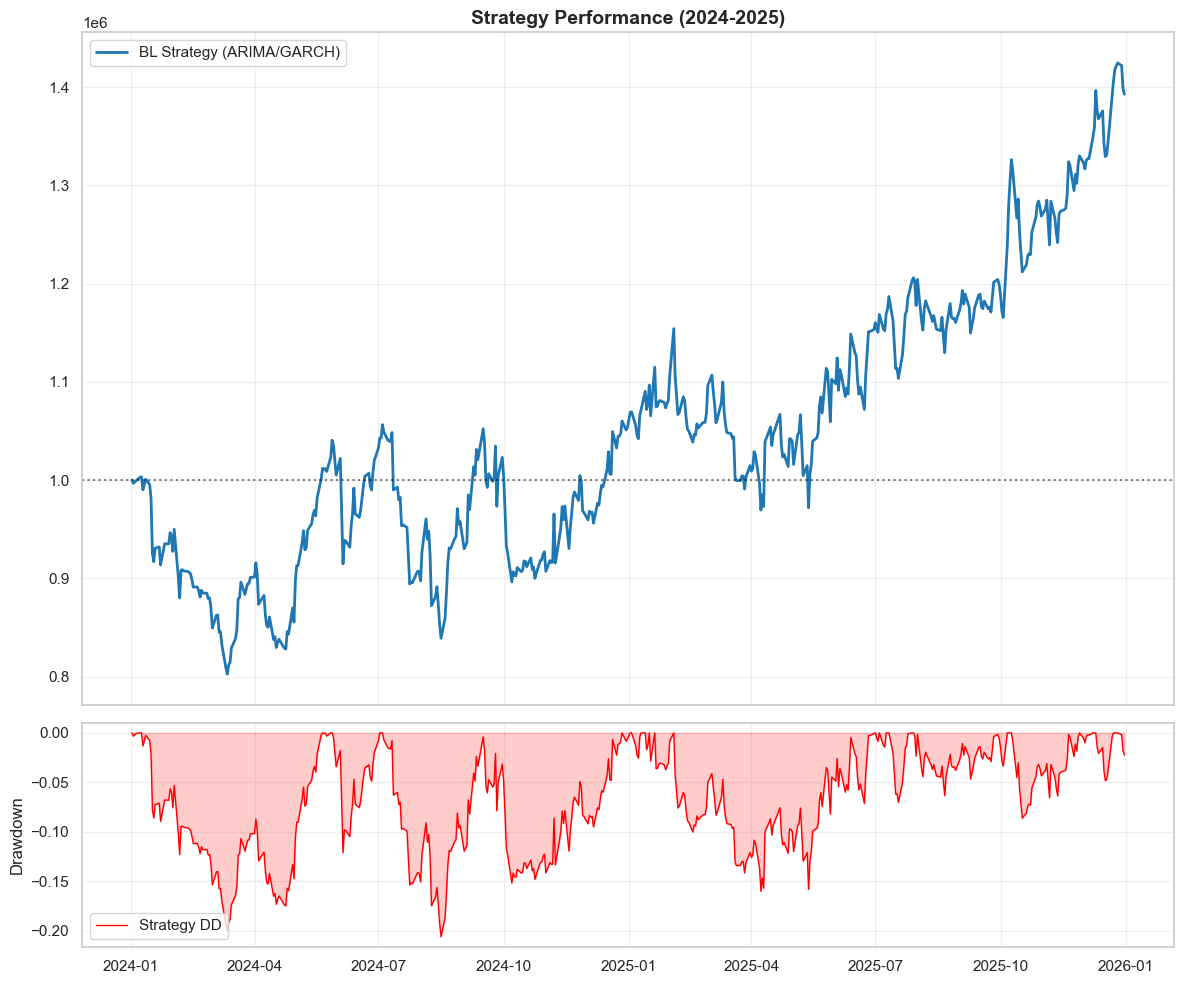